In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    mean_absolute_error, r2_score,
    accuracy_score, classification_report,
    confusion_matrix, precision_score, recall_score
)
from sklearn.preprocessing import PolynomialFeatures

# Section 1: Data Loading and Preprocessing


## 1: Load Dataset


In [3]:
df = pd.read_csv("delivery_data.csv")
print(f"Dataset Shape: {df.shape}")
display(df.head())
df.info()
summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2),
    "Unique Values": df.nunique()
})
display(summary.sort_values("Missing %", ascending=False))
print('\nBasic Statistics:')
df.describe()

Dataset Shape: (2000, 8)


,Distance_km,Prep_Time_min,Courier_Experience_yrs,Weather,Traffic_Level,Vehicle_Type,Delivery_Time_min,Is_Late
0,5.993428,11.624109,7,NaN,High,Scooter,44.013542,0
1,4.723471,14.277407,2,Sunny,High,Car,35.527712,0
2,6.295377,11.037900,9,Rainy,High,Scooter,48.567934,1
3,8.046060,13.460192,7,Sunny,High,Car,50.452710,1
4,4.531693,5.531927,7,Rainy,Medium,Bicycle,47.632817,1


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Distance_km             2000 non-null   float64
 1   Prep_Time_min           1895 non-null   float64
 2   Courier_Experience_yrs  2000 non-null   int64  
 3   Weather                 1893 non-null   str    
 4   Traffic_Level           2000 non-null   str    
 5   Vehicle_Type            2000 non-null   str    
 6   Delivery_Time_min       2000 non-null   float64
 7   Is_Late                 2000 non-null   int64  
dtypes: float64(3), int64(2), str(3)
memory usage: 125.1 KB


,Data Type,Missing,Missing %,Unique Values
Weather,str,107,5.35,4
Prep_Time_min,float64,105,5.25,1850
Distance_km,float64,0,0.00,1982
Courier_Experience_yrs,int64,0,0.00,10
Traffic_Level,str,0,0.00,4
Vehicle_Type,str,0,0.00,3
Delivery_Time_min,float64,0,0.00,1986
Is_Late,int64,0,0.00,2



Basic Statistics:


,Distance_km,Prep_Time_min,Courier_Experience_yrs,Delivery_Time_min,Is_Late
count,2000.000000,1895.000000,2000.000000,2000.000000,2000.000000
mean,5.097968,15.031132,4.552500,53.317833,0.549000
std,1.956540,4.942245,2.885898,27.200221,0.497718
min,0.500000,5.000000,0.000000,10.000000,0.000000
25%,3.754676,11.453845,2.000000,33.683481,0.000000
50%,5.089383,15.033999,5.000000,47.682737,1.000000
75%,6.365955,18.350682,7.000000,67.152951,1.000000
max,12.705463,34.631189,9.000000,183.617375,1.000000


### Define Features and Target — Split Data


In [4]:
# Features matrix and target vector for Regression
X = df.drop(columns=['Delivery_Time_min', 'Is_Late'])
y_reg = df['Delivery_Time_min']   # regression target
y_clf = df['Is_Late']             # classification target

# Train/Test split — 80% train, 20% test — random_state for reproducibility
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)
_, _, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

print(f'Train size: {X_train.shape[0]} samples')
print(f'Test size:  {X_test.shape[0]} samples')
print(f'\nRegression target — Delivery_Time_min (min/max): {y_reg.min():.1f} / {y_reg.max():.1f}')
print(f'Classification target — Is_Late distribution:')
print(y_clf.value_counts())

Train size: 1600 samples
Test size:  400 samples

Regression target — Delivery_Time_min (min/max): 10.0 / 183.6
Classification target — Is_Late distribution:
Is_Late
1    1098
0     902
Name: count, dtype: int64


## 1_2 Build Preprocessing Pipeline (ColumnTransformer)


In [5]:
# Identify numeric and categorical columns
numeric_features    = ['Distance_km', 'Prep_Time_min', 'Courier_Experience_yrs']
categorical_features = ['Weather', 'Traffic_Level', 'Vehicle_Type']

# Numeric pipeline: impute with mean → standardize
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',  StandardScaler())
])

# Categorical pipeline: impute with most_frequent → one-hot encode
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine both pipelines into a ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline,    numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Section 2: Delivery Time Prediction (Regression)


## 2_1 Baseline Linear Regression


In [6]:
# Build pipeline: preprocessor + Linear Regression
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',        LinearRegression())
])

# Train on training data
lr_pipeline.fit(X_train, y_train_reg)

# Predict on test data
y_pred_lr = lr_pipeline.predict(X_test)

# Evaluate
mae_lr = mean_absolute_error(y_test_reg, y_pred_lr)
r2_lr  = r2_score(y_test_reg, y_pred_lr)

print('____ Baseline Linear Regression ____')
print(f'MAE (Mean Absolute Error): {mae_lr:.2f} minutes')
print(f'R² Score:                  {r2_lr:.4f}')
print(f'\nOn average, predictions are off by {mae_lr:.2f} minutes.')

____ Baseline Linear Regression ____
MAE (Mean Absolute Error): 6.95 minutes
R² Score:                  0.8807

On average, predictions are off by 6.95 minutes.


## 2_2 Bias-Variance Tradeoff : Polynomial Features (degree=2)


In [7]:
# Polynomial pipeline: preprocessor → PolynomialFeatures(degree=2) → LinearRegression
poly_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('poly',         PolynomialFeatures(degree=2, include_bias=False)),
    ('model',        LinearRegression())
])

poly_pipeline.fit(X_train, y_train_reg)
y_pred_poly = poly_pipeline.predict(X_test)

mae_poly_test  = mean_absolute_error(y_test_reg, y_pred_poly)
r2_poly_test   = r2_score(y_test_reg, y_pred_poly)

y_pred_poly_train = poly_pipeline.predict(X_train)
r2_poly_train     = r2_score(y_train_reg, y_pred_poly_train)

print('___ Polynomial Regression (degree=2) ____')
print(f'Train R²: {r2_poly_train:.4f}')
print(f'Test  R²: {r2_poly_test:.4f}')
print(f'Test MAE: {mae_poly_test:.2f} minutes')

gap = r2_poly_train - r2_poly_test
print(f'\nTrain-Test R² Gap: {gap:.4f}')
if gap > 0.05:
    print('→ The model shows signs of OVERFITTING (train R² significantly higher than test R²).')
else:
    print('→ No significant overfitting detected.')

if r2_poly_test > r2_lr:
    print(f'→ R² improved from {r2_lr:.4f} (linear) to {r2_poly_test:.4f} (polynomial).')
else:
    print(f'→ R² did NOT improve: linear={r2_lr:.4f}, polynomial={r2_poly_test:.4f}.')

___ Polynomial Regression (degree=2) ____
Train R²: 0.9500
Test  R²: 0.9470
Test MAE: 4.64 minutes

Train-Test R² Gap: 0.0030
→ No significant overfitting detected.
→ R² improved from 0.8807 (linear) to 0.9470 (polynomial).


## 2_3 Regularization : Ridge Regression + GridSearchCV


In [8]:
# Ridge pipeline: preprocessor → PolynomialFeatures → Ridge
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('poly',         PolynomialFeatures(degree=2, include_bias=False)),
    ('model',        Ridge())
])

# Hyperparameter grid for alpha
param_grid = {'model__alpha': [0.1, 1.0, 10.0]}

# GridSearchCV — 5-fold cross-validation, optimizing R²
grid_search = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_train, y_train_reg)

print('___ Ridge Regression with GridSearchCV ___')
print(f'Best Alpha:     {grid_search.best_params_["model__alpha"]}')
print(f'Best CV R²:     {grid_search.best_score_:.4f}')

# Evaluate best model on test set
y_pred_ridge = grid_search.predict(X_test)
mae_ridge    = mean_absolute_error(y_test_reg, y_pred_ridge)
r2_ridge     = r2_score(y_test_reg, y_pred_ridge)
print(f'Test MAE:       {mae_ridge:.2f} minutes')
print(f'Test R²:        {r2_ridge:.4f}')

# CV results summary
print('\nGridSearchCV Results:')
cv_results = pd.DataFrame(grid_search.cv_results_)[['param_model__alpha', 'mean_test_score', 'std_test_score']]
cv_results.columns = ['Alpha', 'Mean CV R²', 'Std CV R²']
print(cv_results.to_string(index=False))

___ Ridge Regression with GridSearchCV ___
Best Alpha:     1.0
Best CV R²:     0.9457
Test MAE:       4.64 minutes
Test R²:        0.9470

GridSearchCV Results:
 Alpha  Mean CV R²  Std CV R²
   0.1    0.945653   0.008126
   1.0    0.945681   0.008103
  10.0    0.945390   0.007938


# Section 3: Late Delivery Prediction (Classification)


## 3_1 Compare Three Classification Models


In [9]:
# Define three classifiers with their pipelines
classifiers = {
    'Logistic Regression':LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':RandomForestClassifier(n_estimators=100, random_state=42),
    'Support Vector Machine':SVC(kernel='rbf', random_state=42)
}

results = {}
clf_pipelines = {}

for name, clf in classifiers.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model',        clf)
    ])
    pipe.fit(X_train, y_train_clf)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test_clf, y_pred)
    results[name] = acc
    clf_pipelines[name] = pipe
    print(f'{name:<30} Accuracy: {acc:.4f} ({acc*100:.2f}%)')

best_model_name = max(results, key=results.get)
print(f'\nBest Model: {best_model_name} with accuracy {results[best_model_name]:.4f}')

Logistic Regression            Accuracy: 0.9325 (93.25%)
Random Forest                  Accuracy: 0.9125 (91.25%)
Support Vector Machine         Accuracy: 0.9300 (93.00%)

Best Model: Logistic Regression with accuracy 0.9325


## 3_2 Detailed Evaluation of Best Model


In [10]:
best_pipeline = clf_pipelines[best_model_name]
y_pred_best   = best_pipeline.predict(X_test)

precision = precision_score(y_test_clf, y_pred_best)
recall    = recall_score(y_test_clf, y_pred_best)

print(f'____ Best Model: {best_model_name} ____')
print(f'Accuracy:  {accuracy_score(y_test_clf, y_pred_best):.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'\nFull Classification Report:\n{classification_report(y_test_clf, y_pred_best, target_names=['On Time', 'Late'])}')


____ Best Model: Logistic Regression ____
Accuracy:  0.9325
Precision: 0.9362
Recall:    0.9483

Full Classification Report:
              precision    recall  f1-score   support

     On Time       0.93      0.91      0.92       168
        Late       0.94      0.95      0.94       232

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400



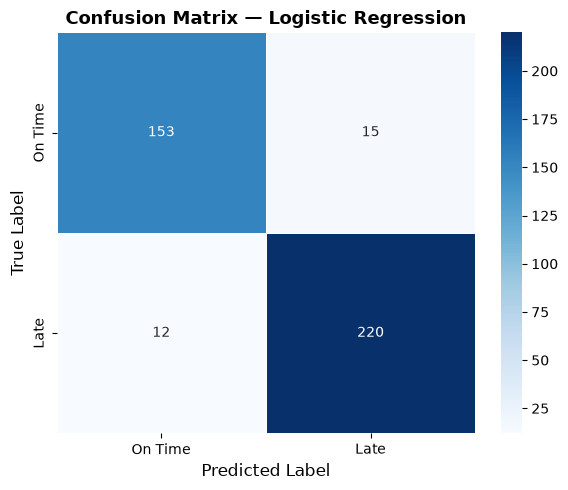

Confusion Matrix saved as confusion_matrix.png


In [11]:
# Plot Confusion Matrix using Seaborn
cm = confusion_matrix(y_test_clf, y_pred_best)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['On Time', 'Late'],
    yticklabels=['On Time', 'Late'],
    linewidths=0.5, ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion Matrix saved as confusion_matrix.png')

## Business Interpretation: False Negative vs False Positive


In [12]:
tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (On Time predicted as On Time): {tn}')
print(f'False Positives (On Time predicted as Late):    {fp}')
print(f'False Negatives (Late predicted as On Time):    {fn}')
print(f'True Positives  (Late predicted as Late):       {tp}')

True Negatives  (On Time predicted as On Time): 153
False Positives (On Time predicted as Late):    15
False Negatives (Late predicted as On Time):    12
True Positives  (Late predicted as Late):       220


###  Business Interpretation 

>For a delivery company, FALSE NEGATIVES are MORE HARMFUL than False Positives.

- False Negative: We predict the order will arrive ON TIME, but it actually arrives LATE.
  → The customer is surprised by a delay with NO prior warning or discount offer.
  → This destroys customer trust and satisfaction.

- False Positive: We predict the order will be LATE, but it actually arrives ON TIME.
  → We send a discount code or apology unnecessarily.
  → Cost: a small discount, but the customer is pleasantly surprised.

>Conclusion: Minimizing False Negatives (maximizing Recall) is the priority.
>A late delivery without warning is far more damaging than an unnecessary apology.

# Section 4: Model Interpretation — Feature Importance


## 4_1 Extract Linear Regression Coefficients


In [13]:
# Get feature names from the preprocessor after fitting
feature_names = lr_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Extract coefficients from the linear regression model
coefficients = lr_pipeline.named_steps['model'].coef_

# Build a DataFrame of feature name → coefficient
coef_df = pd.DataFrame({
    'Feature':     feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=False)

print('All Features and their Coefficients (sorted):')
print(coef_df.to_string(index=False))

# Top 5 features with highest coefficient (most impact on delivery time)
top5 = coef_df.head()
print('\nTop 5 Features with Highest Positive Impact:')
print(top5.to_string(index=False))

All Features and their Coefficients (sorted):
                    Feature  Coefficient
     cat__Traffic_Level_Jam    22.223718
  cat__Vehicle_Type_Bicycle    18.230763
         cat__Weather_Snowy    11.539880
           num__Distance_km    10.312148
         num__Prep_Time_min     8.890329
    cat__Traffic_Level_High     3.087440
         cat__Weather_Rainy     2.295464
num__Courier_Experience_yrs    -1.523803
         cat__Weather_Foggy    -2.225118
  cat__Vehicle_Type_Scooter    -6.122657
  cat__Traffic_Level_Medium    -8.743449
         cat__Weather_Sunny   -11.610227
      cat__Vehicle_Type_Car   -12.108106
     cat__Traffic_Level_Low   -16.567709

Top 5 Features with Highest Positive Impact:
                  Feature  Coefficient
   cat__Traffic_Level_Jam    22.223718
cat__Vehicle_Type_Bicycle    18.230763
       cat__Weather_Snowy    11.539880
         num__Distance_km    10.312148
       num__Prep_Time_min     8.890329


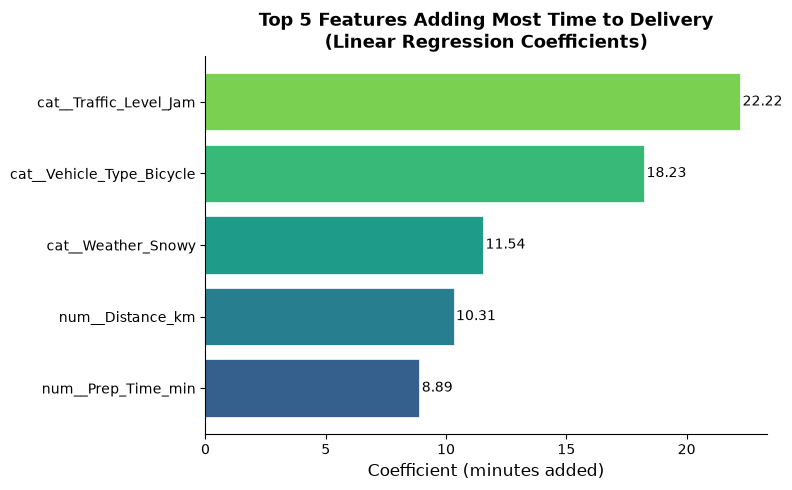


The factor with the HIGHEST impact is: cat__Traffic_Level_Jam
It adds approximately 22.22 minutes to delivery time.


In [14]:
# Bar plot of top 5 features
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(
    top5['Feature'][::-1],
    top5['Coefficient'][::-1],
    color=plt.cm.viridis(np.linspace(0.3, 0.8, len(top5))),
    edgecolor='white',
    linewidth=0.5
)

# Add value labels on bars
for bar, val in zip(bars, top5['Coefficient'][::-1]):
    ax.text(
        bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
        f'{val:.2f}', va='center', fontsize=10
    )

ax.set_xlabel('Coefficient (minutes added)', fontsize=12)
ax.set_title('Top 5 Features Adding Most Time to Delivery\n(Linear Regression Coefficients)', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

top_feature = top5.iloc[0]['Feature']
top_coef = top5.iloc[0]['Coefficient']
print(f'\nThe factor with the HIGHEST impact is: {top_feature}')
print(f'It adds approximately {top_coef:.2f} minutes to delivery time.')

### Answer:
> Heavy traffic (Jam) is the strongest factor, adding more than 22 minutes to delivery time alone, which is almost double the effect of snowy weather (+11.5 minutes).
>This conclusion makes sense: in full traffic, even short routes take a long time, but snowy weather also limits the risk and speed, ranking third.
>It is interesting that the bicycle ranks second as a means of transport, because over long distances or in bad conditions, it operates much slower than a scooter or car.

## Summary of All Model Results


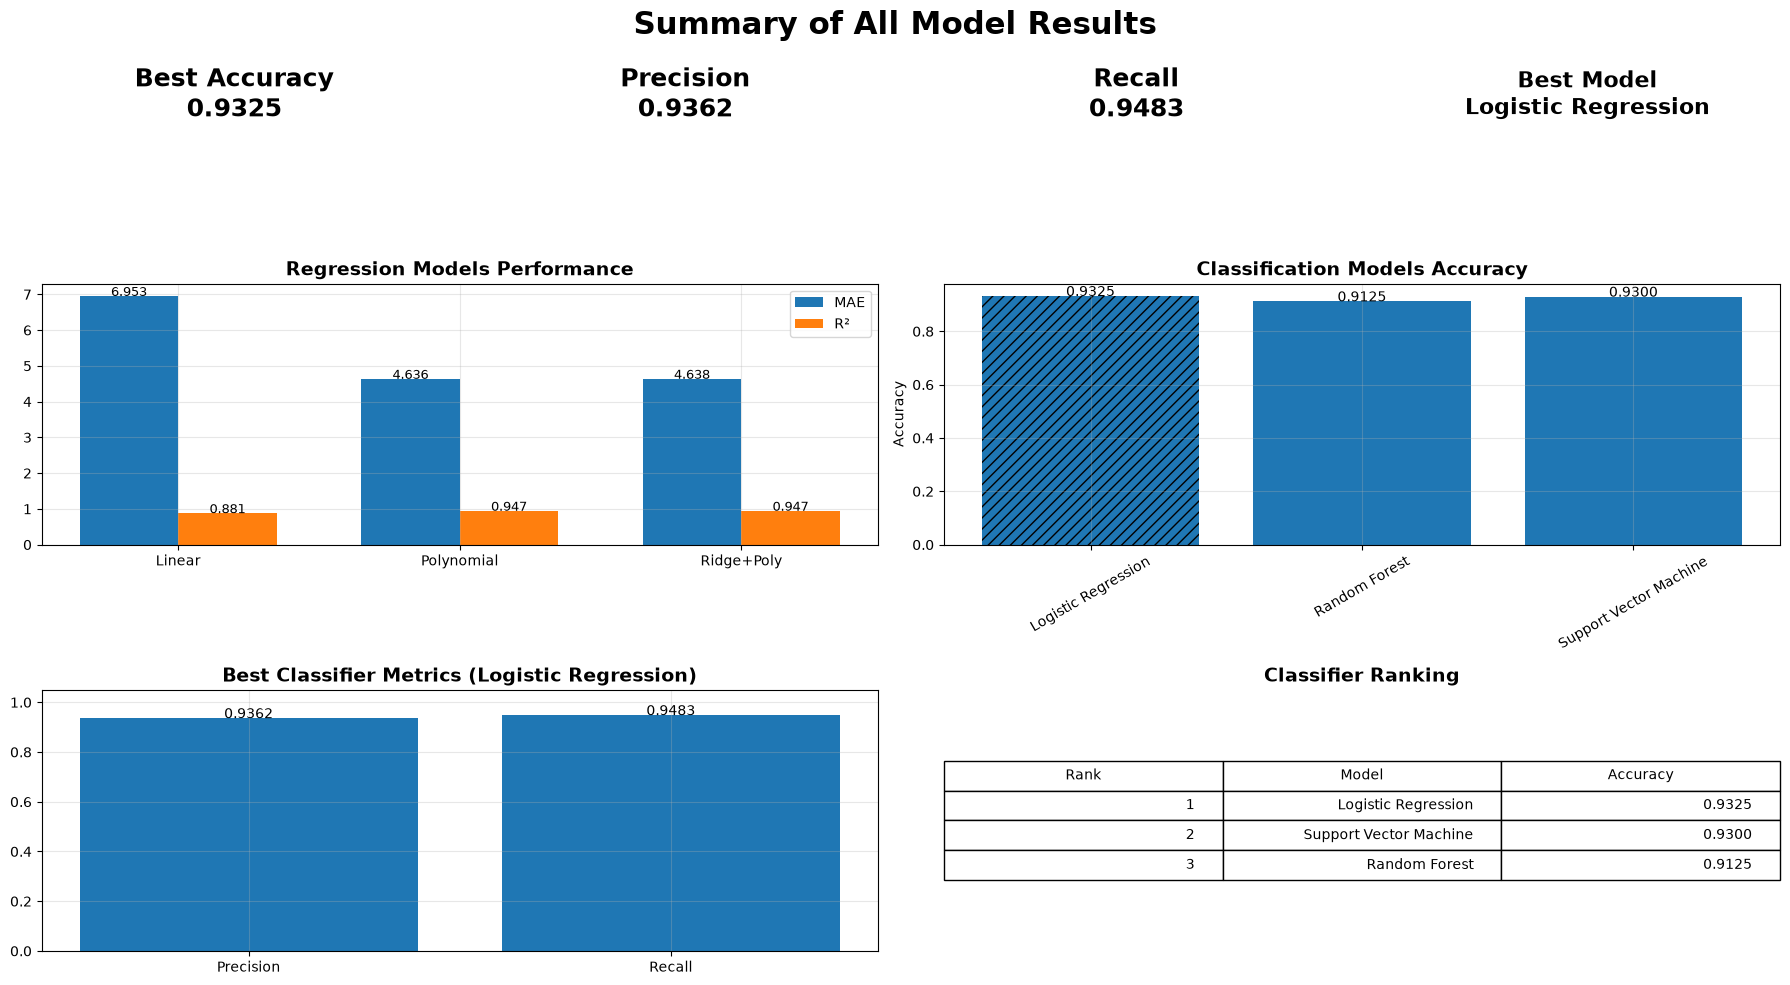

In [16]:
# Data
reg_models = [
    'Linear',
    'Polynomial',
    'Ridge+Poly'
]

mae_values = [mae_lr, mae_poly_test, mae_ridge]
r2_values = [r2_lr, r2_poly_test, r2_ridge]

clf_models = list(results.keys())
accuracies = list(results.values())

best_accuracy = max(accuracies)

# Dashboard Layout
fig = plt.figure(figsize=(18, 10))

gs = fig.add_gridspec(
    3,
    4,
    height_ratios=[1, 3, 3]
)

# KPI CARDS
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[0, 3])

for ax in [ax1, ax2, ax3, ax4]:
    ax.axis('off')

ax1.text(
    0.5, 0.5,
    f'Best Accuracy\n{best_accuracy:.4f}',
    ha='center',
    va='center',
    fontsize=18,
    fontweight='bold'
)

ax2.text(
    0.5, 0.5,
    f'Precision\n{precision:.4f}',
    ha='center',
    va='center',
    fontsize=18,
    fontweight='bold'
)

ax3.text(
    0.5, 0.5,
    f'Recall\n{recall:.4f}',
    ha='center',
    va='center',
    fontsize=18,
    fontweight='bold'
)

ax4.text(
    0.5, 0.5,
    f'Best Model\n{best_model_name}',
    ha='center',
    va='center',
    fontsize=16,
    fontweight='bold'
)

# Regression Comparison
ax_reg = fig.add_subplot(gs[1, :2])

x = np.arange(len(reg_models))
width = 0.35

bars1 = ax_reg.bar(
    x - width/2,
    mae_values,
    width,
    label='MAE'
)

bars2 = ax_reg.bar(
    x + width/2,
    r2_values,
    width,
    label='R²'
)

ax_reg.set_title(
    'Regression Models Performance',
    fontsize=14,
    fontweight='bold'
)

ax_reg.set_xticks(x)
ax_reg.set_xticklabels(reg_models)

ax_reg.legend()
ax_reg.grid(True, alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax_reg.text(
            bar.get_x() + bar.get_width()/2,
            h,
            f'{h:.3f}',
            ha='center',
            fontsize=9
        )

# Classification Accuracy
ax_clf = fig.add_subplot(gs[1, 2:])

bars = ax_clf.bar(
    clf_models,
    accuracies
)

best_idx = accuracies.index(best_accuracy)

bars[best_idx].set_hatch('///')

ax_clf.set_title(
    'Classification Models Accuracy',
    fontsize=14,
    fontweight='bold'
)

ax_clf.set_ylabel('Accuracy')
ax_clf.tick_params(axis='x', rotation=30)
ax_clf.grid(True, alpha=0.3)

for bar in bars:
    h = bar.get_height()
    ax_clf.text(
        bar.get_x() + bar.get_width()/2,
        h,
        f'{h:.4f}',
        ha='center'
    )

# Precision vs Recall
ax_metrics = fig.add_subplot(gs[2, :2])

metrics = ['Precision', 'Recall']
values = [precision, recall]

bars = ax_metrics.bar(metrics, values)

ax_metrics.set_ylim(0, 1.05)

ax_metrics.set_title(
    f'Best Classifier Metrics ({best_model_name})',
    fontsize=14,
    fontweight='bold'
)

ax_metrics.grid(True, alpha=0.3)

for bar in bars:
    h = bar.get_height()
    ax_metrics.text(
        bar.get_x() + bar.get_width()/2,
        h,
        f'{h:.4f}',
        ha='center'
    )

# Ranking Table
ax_rank = fig.add_subplot(gs[2, 2:])
ax_rank.axis('off')

sorted_models = sorted(
    results.items(),
    key=lambda x: x[1],
    reverse=True
)

table_data = [
    [i+1, name, f'{acc:.4f}']
    for i, (name, acc) in enumerate(sorted_models)
]

table = ax_rank.table(
    cellText=table_data,
    colLabels=['Rank', 'Model', 'Accuracy'],
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

ax_rank.set_title(
    'Classifier Ranking',
    fontsize=14,
    fontweight='bold'
)

# Final Touch
fig.suptitle(
    'Summary of All Model Results',
    fontsize=22,
    fontweight='bold'
)

plt.tight_layout()
plt.show()